# 🧠 DL Tuning Challenge — Starter Notebook

**Mata Kuliah:** DSB07 – Machine Learning  
**Topik:** Hyperparameter Tuning pada Deep Neural Network  
**Dataset:** Fashion-MNIST (10 kelas pakaian, 28×28 grayscale)

## Instruksi

1. **Jalankan SEMUA cell** dari atas ke bawah untuk mendapatkan baseline.
2. Ubah hyperparameter HANYA di section **🎛️ HYPERPARAMETER PANEL**.
3. **JANGAN** mengubah cell ber-label **🔒 LOCKED**.
4. Catat setiap eksperimen di `EXPERIMENTS.md`.

> 💡 **Tips:** Aktifkan GPU runtime: `Runtime → Change runtime type → T4 GPU`

## 🔒 LOCKED — Setup & Data Loading

**Jangan ubah cell ini.** Cell ini me-load dataset dengan cara yang sama untuk semua kelompok agar penilaian adil.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28),  Test: (10000, 28, 28)
Jumlah kelas: 10


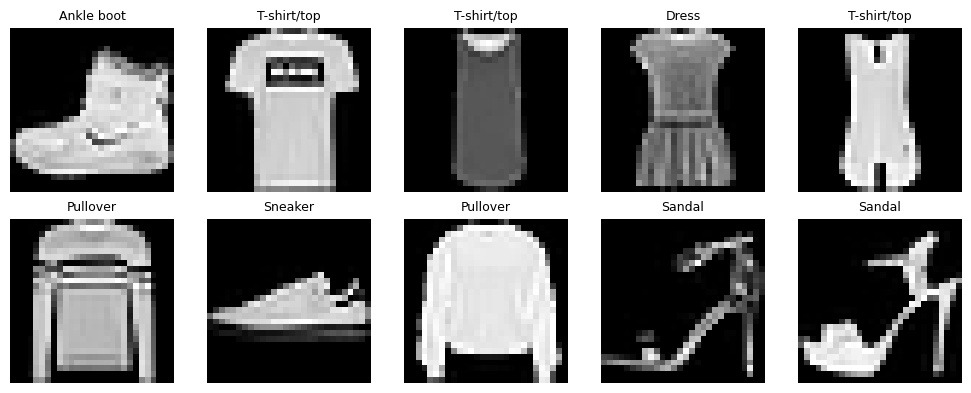

In [1]:
# 🔒 LOCKED — JANGAN UBAH
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# Reproducibility — jangan ubah seed ini
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Load Fashion-MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalisasi ke [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten 28x28 → 784 (untuk MLP sederhana)
x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f'Train: {x_train.shape},  Test: {x_test.shape}')
print(f'Jumlah kelas: {len(CLASS_NAMES)}')

# Visualisasi sample
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(CLASS_NAMES[y_train[i]], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 🎛️ HYPERPARAMETER PANEL

**Ini area bermain kalian.** Ubah nilai-nilai di bawah dan amati pengaruhnya.

Setiap variabel di bawah memetakan langsung ke konsep yang dipelajari di kelas:

| Variabel | Konsep di Slide |
|---|---|
| `HIDDEN_LAYERS` | Jumlah Lapisan |
| `NEURONS_PER_LAYER` | Jumlah Neuron |
| `ACTIVATION` | Fungsi Aktivasi |
| `OPTIMIZER` | Optimizer (Adam, SGD, dst) |
| `LEARNING_RATE` | Learning Rate (λ) |
| `BATCH_SIZE` | Batch Size |
| `EPOCHS` | Epoch |
| `DROPOUT_RATE` | (Bonus) regularisasi |

In [2]:
# 🎛️ UBAH NILAI-NILAI DI BAWAH INI

# --- Arsitektur Model ---
HIDDEN_LAYERS     = 3            # jumlah hidden layer (coba: 1, 2, 3, 4, 5)
NEURONS_PER_LAYER = 256           # jumlah neuron per hidden layer (coba: 32, 64, 128, 256, 512)
ACTIVATION        = 'relu'       # 'relu', 'tanh', 'sigmoid', 'elu', 'selu'
DROPOUT_RATE      = 0.2          # 0.0 = tidak ada dropout. Coba 0.2 / 0.3 / 0.5 untuk regularisasi

# --- Optimizer & Pelatihan ---
OPTIMIZER     = 'adamax'            # 'sgd', 'adam', 'adamax', 'rmsprop'
LEARNING_RATE = 0.0001             # coba: 0.0001, 0.001, 0.01, 0.1, 1.0
BATCH_SIZE    = 32               # coba: 16, 32, 64, 128, 256, 512
EPOCHS        = 30               # coba: 5, 10, 20, 50

# --- Catatan untuk eksperimen ini (akan dicetak di summary) ---
EXPERIMENT_NOTE = 'Baseline run — belum di-tuning'

## 🔒 LOCKED — Model Builder

Cell ini membangun model berdasarkan hyperparameter di atas. Tidak perlu diubah.

In [3]:
# 🔒 LOCKED — JANGAN UBAH

def build_model():
    """Bangun MLP berdasarkan hyperparameter panel."""
    model = keras.Sequential(name='TuningChallengeModel')
    model.add(keras.layers.Input(shape=(784,)))

    for i in range(HIDDEN_LAYERS):
        model.add(keras.layers.Dense(
            NEURONS_PER_LAYER,
            activation=ACTIVATION,
            name=f'hidden_{i+1}'
        ))
        if DROPOUT_RATE > 0:
            model.add(keras.layers.Dropout(DROPOUT_RATE))

    # Output layer — 10 kelas, JANGAN diubah
    model.add(keras.layers.Dense(10, activation='softmax', name='output'))
    return model


def get_optimizer():
    """Map string optimizer ke Keras optimizer dengan learning rate."""
    opts = {
        'sgd':     keras.optimizers.SGD(learning_rate=LEARNING_RATE),
        'adam':    keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        'adamax':  keras.optimizers.Adamax(learning_rate=LEARNING_RATE),
        'rmsprop': keras.optimizers.RMSprop(learning_rate=LEARNING_RATE),
    }
    if OPTIMIZER.lower() not in opts:
        raise ValueError(f'Optimizer "{OPTIMIZER}" tidak dikenal. Pilih: {list(opts.keys())}')
    return opts[OPTIMIZER.lower()]


# Build & compile
model = build_model()
model.compile(
    optimizer=get_optimizer(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Hitung total parameter (bobot + bias) — visualisasikan konsep 'parameter'
total_params = model.count_params()
print(f'\n📊 Total parameter (bobot + bias) yang akan di-learn: {total_params:,}')

Model: "TuningChallengeModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 335,114 (1.28 MB)

 Trainable params: 335,114 (1.28 MB)

 Non-trainable params: 0 (0.00 B)


📊 Total parameter (bobot + bias) yang akan di-learn: 335,114


## 🔒 LOCKED — Training

Cell ini menjalankan **feed forward + back propagation** sesuai jumlah epoch yang kalian tentukan.

In [4]:
# 🔒 LOCKED — JANGAN UBAH

import time

start = time.time()
history = model.fit(
    x_train_flat, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1,   # 10% dari training jadi validation
    verbose=1
)
duration = time.time() - start
print(f'\n⏱️  Total waktu training: {duration:.1f} detik')

Epoch 1/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.6357 - loss: 1.0568 - val_accuracy: 0.7870 - val_loss: 0.6026
Epoch 2/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.7742 - loss: 0.6454 - val_accuracy: 0.8212 - val_loss: 0.5078
Epoch 3/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.8074 - loss: 0.5546 - val_accuracy: 0.8345 - val_loss: 0.4621
Epoch 4/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.8218 - loss: 0.5088 - val_accuracy: 0.8417 - val_loss: 0.4375
Epoch 5/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8333 - loss: 0.4771 - val_accuracy: 0.8480 - val_loss: 0.4162
Epoch 6/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.8409 - loss: 0.4504 - val_accuracy: 0.8537 - val_loss: 0.4019
Epoch 7/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.8464 - loss: 0.4326 - val_accuracy: 0.8558 - val_loss: 0.3921
Epoch 8/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.8515 - los

## 🔒 LOCKED — Evaluasi & Visualisasi

📝 Catatan: Baseline run — belum di-tuning
Hyperparameter:
  Hidden layers     : 3
  Neurons per layer : 256
  Activation        : relu
  Dropout rate      : 0.2
  Optimizer         : adamax
  Learning rate     : 0.0001
  Batch size        : 32
  Epochs            : 30
------------------------------------------------------------
🎯 TEST ACCURACY  : 88.11%
   Test loss      : 0.3386
   Train accuracy : 89.30%
   Val accuracy   : 88.73%


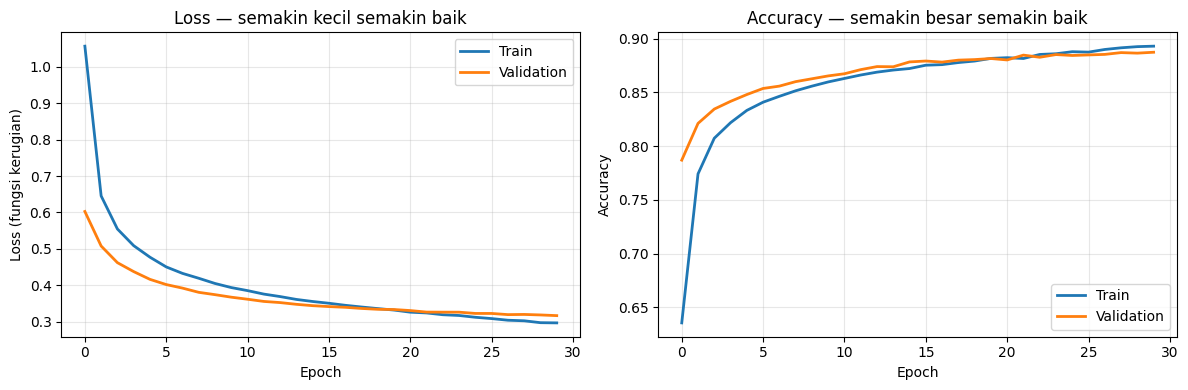

✅ Train-val gap sehat. Lanjut eksperimen!


In [5]:
# 🔒 LOCKED — JANGAN UBAH

# Evaluasi pada test set
test_loss, test_acc = model.evaluate(x_test_flat, y_test, verbose=0)

print('='*60)
print(f'📝 Catatan: {EXPERIMENT_NOTE}')
print('='*60)
print(f'Hyperparameter:')
print(f'  Hidden layers     : {HIDDEN_LAYERS}')
print(f'  Neurons per layer : {NEURONS_PER_LAYER}')
print(f'  Activation        : {ACTIVATION}')
print(f'  Dropout rate      : {DROPOUT_RATE}')
print(f'  Optimizer         : {OPTIMIZER}')
print(f'  Learning rate     : {LEARNING_RATE}')
print(f'  Batch size        : {BATCH_SIZE}')
print(f'  Epochs            : {EPOCHS}')
print('-'*60)
print(f'🎯 TEST ACCURACY  : {test_acc*100:.2f}%')
print(f'   Test loss      : {test_loss:.4f}')
print(f'   Train accuracy : {history.history["accuracy"][-1]*100:.2f}%')
print(f'   Val accuracy   : {history.history["val_accuracy"][-1]*100:.2f}%')
print('='*60)

# Plot training curves — visualisasi konkret dari proses backpropagation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (fungsi kerugian)')
axes[0].set_title('Loss — semakin kecil semakin baik')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy — semakin besar semakin baik')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Diagnostik kecil
gap = history.history['accuracy'][-1] - history.history['val_accuracy'][-1]
if gap > 0.05:
    print(f'⚠️  Gap train vs val = {gap*100:.1f}% — kemungkinan OVERFITTING.')
    print('    Coba: kurangi neuron, tambah dropout, atau kurangi epoch.')
elif history.history['accuracy'][-1] < 0.7:
    print('⚠️  Akurasi train rendah — kemungkinan UNDERFITTING.')
    print('    Coba: tambah neuron/layer, naikkan learning rate, atau tambah epoch.')
else:
    print('✅ Train-val gap sehat. Lanjut eksperimen!')

## 🔍 (Opsional) Inspect Confusion Matrix

Kelas mana yang paling sering tertukar? Insight ini bisa membantu argumentasi di refleksi kalian.

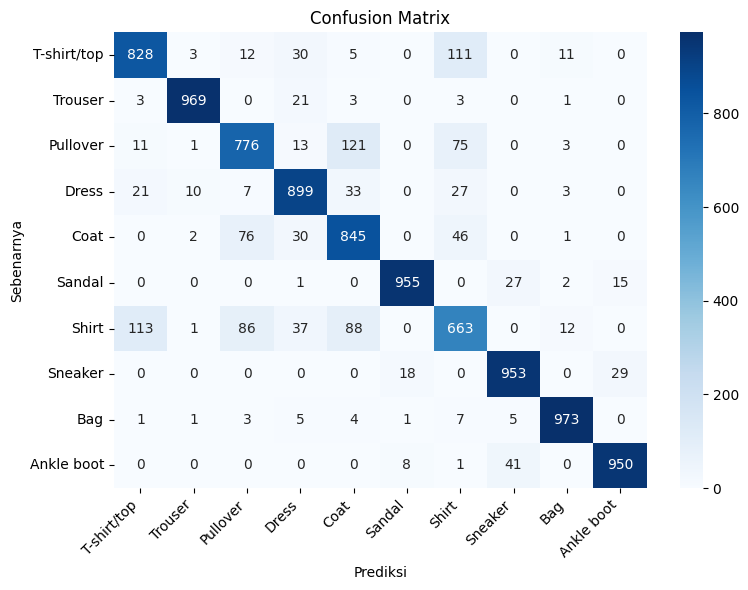

In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(x_test_flat, verbose=0).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Prediksi')
plt.ylabel('Sebenarnya')
plt.title('Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---

## ✅ Checklist Setelah Eksperimen Ini

- [ ] Catat hasilnya di `EXPERIMENTS.md`
- [ ] Diskusikan dengan tim: *mengapa* hasilnya seperti ini?
- [ ] Tentukan apa yang akan diubah pada eksperimen berikutnya — dan **kenapa**
- [ ] Setelah ≥5 eksperimen, pilih konfigurasi terbaik → simpan sebagai `solution.ipynb`
- [ ] Tulis refleksi di `REFLECTION.md`